### Homework 2

Damion Huppert

In [31]:
using Pkg
using Plots
using JuMP
using HiGHS

Pkg.add("DataFrames")
Pkg.add("CSV")
Pkg.add("NamedArrays")
using DataFrames
using CSV
using NamedArrays


   Resolving package versions...
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\damio\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
   Installed Combinatorics ─ v1.0.2
   Installed NamedArrays ─── v0.10.3
    Updating `C:\Users\damio\.julia\environments\v1.11\Project.toml`
  [86f7a689] + NamedArrays v0.10.3
    Updating `C:\Users\damio\.julia\environments\v1.11\Manifest.toml`
  [861a8166] + Combinatorics v1.0.2
  [86f7a689] + NamedArrays v0.10.3
Precompiling project...
    826.2 ms  ✓ Combinatorics
   1247.8 ms  ✓ NamedArrays
  2 dependencies successfully precompiled in 3 seconds. 254 already precompiled.


##### Question 1-1

Decision variables:  
- $x_1$ = Hours to run process 1  
- $x_2$ = Hours to run process 2  

Then a linear program that will minimize his cost will be:  

$$\min \quad 4x_1 + x_2$$  

Subject to:  

$$3x_1 + x_2 \geq 10  \quad \text{(Vial A constraint)}$$  
$$x_1 + x_2 \geq 5  \quad \text{(Vial B constraint)}$$  
$$x_1 \geq 3  \quad \text{(Vial C constraint)}$$  

$$x_1, x_2 \geq 0$$  


##### Question 1-2

In [8]:
m = Model(HiGHS.Optimizer)

@variable(m, x1 >= 0)
@variable(m, x2 >= 0)

@constraint(m, 3*x1 + x2 >= 10)
@constraint(m, x1 + x2 >= 5)
@constraint(m, x1 >= 3)

@objective(m, Min, 4*x1 + x2)

optimize!(m)

println("optimal hours to run x1: ", value(x1))
println("optimal hours to run x2: ", value(x2))
println("optimal cost value: ", objective_value(m))

Running HiGHS 1.9.0 (git hash: 66f735e60): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e+00, 3e+00]
  Cost   [1e+00, 4e+00]
  Bound  [0e+00, 0e+00]
  RHS    [3e+00, 1e+01]
Presolving model
2 rows, 2 cols, 4 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve : Reductions: rows 0(-3); columns 0(-2); elements 0(-5) - Reduced to empty
Solving the original LP from the solution after postsolve
Model status        : Optimal
Objective value     :  1.4000000000e+01
Relative P-D gap    :  0.0000000000e+00
HiGHS run time      :          0.00
optimal hours to run x1: 3.0
optimal hours to run x2: 2.0
optimal cost value: 14.0


##### Question 1-3

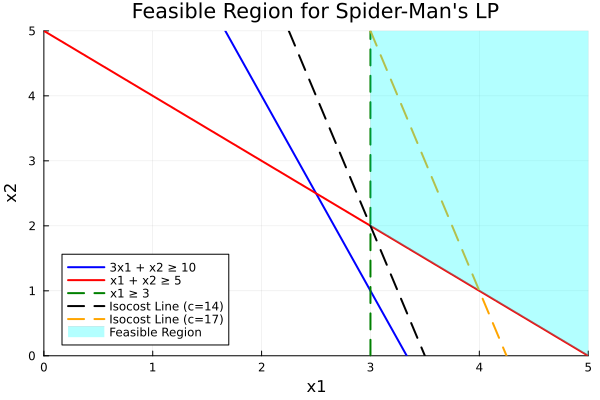

In [28]:
x1_range = 0:0.1:10
f1(x1) = 10 - 3*x1 
f2(x1) = 5 - x1
f3(x1) = 3

plot(x1_range, f1.(x1_range), label="3x1 + x2 ≥ 10", lw=2, color=:blue)
plot!(x1_range, f2.(x1_range), label="x1 + x2 ≥ 5", lw=2, color=:red)
plot!([3, 3], [0, 10], label="x1 ≥ 3", lw=2, color=:green, linestyle=:dash)

# isocost lines
isocostLine(x1) = c - 4*x1
c = 14
plot!(x1_range, isocost_line.(x1_range), label="Isocost Line (c=14)", linestyle=:dash, lw=2, color=:black)
c = 17
plot!(x1_range, isocost_line.(x1_range), label="Isocost Line (c=17)", linestyle=:dash, lw=2, color=:orange)

# feasiable region
x_vals = [3, 3, 5, 5, 3]
y_vals = [2, 5, 5, 0, 2]
plot!(x_vals, y_vals, fill=(0, :cyan, 0.3), lw=0, label="Feasible Region")

xlabel!("x1")
ylabel!("x2")

title!("Feasible Region for Spider-Man's LP")

xlims!(0, 5)
ylims!(0, 5)


##### Questoin 1-4

Decision variables:  
- $x_j$ = Hours to run process $j$  

Then a linear program that will minimize cost will be:  

$$\min \quad \sum_{j \in J} c_jx_j$$  

Subject to:  

$$ \sum_{j \in J} a_{ij} x_j \geq b_i, \quad \forall i \in I$$
$$x_j \geq 0 \quad \forall j \in J$$  


In [32]:
df = CSV.read("spider-man.csv", DataFrame, delim =',') 

# Processes are column names starting at the 3rd
J = propertynames(df)[3:end]

# Chemicals are the first column starting at the second row
I = convert(Array, df[2:end,1])

# Cost
c = Dict(zip(J,df[1,3:end]))

# Amt. required
b = Dict(zip(I,df[2:end,2]))

# Matrix of data 
A = Matrix(df[2:end,3:end])

# Make it a Named Array
A_NA = NamedArray(A, (I,J), ("Chemical", "Process")) 

20×50 Named Matrix{Int64}
Chemical ╲ Process │  process_1   process_2  …  process_49  process_50
───────────────────┼──────────────────────────────────────────────────
chemical_1         │          4           0  …           1           0
chemical_2         │          0           0              3           0
chemical_3         │          3           0              3           0
chemical_4         │          0           0              0           0
chemical_5         │          3           0              1           0
chemical_6         │          0           0              2           4
chemical_7         │          0           2              0           4
chemical_8         │          1           2              0           3
chemical_9         │          0           4              4           1
chemical_10        │          0           0              2           1
chemical_11        │          0           2              0           0
chemical_12        │          2           3        

In [36]:
m = Model(HiGHS.Optimizer)
@variable(m, x[J] >= 0)

@objective(m, Min, sum(c[j]*x[j] for j in J))

@constraint(m, [i in I], sum(A_NA[i,j]*x[j] for j in J) >= b[i])

# If you don't want the solver output, you can try this
set_silent(m)
optimize!(m)

println("Termination status: ", termination_status(m))

sol = Dict(j => value(x[j]) for j in J if value(x[j]) > 1.0e-6)
using Printf
@printf("\nMinimum cost is \$%.2f\n", objective_value(m))
for (key, value) in sol
  @printf("Run %s for %.2f hours\n", key, value)
end

Termination status: OPTIMAL

Minimum cost is $1433.72
Run process_38 for 2.89 hours
Run process_42 for 1.01 hours
Run process_29 for 4.84 hours
Run process_20 for 16.13 hours
Run process_45 for 9.84 hours
Run process_4 for 12.36 hours
Run process_50 for 0.90 hours
Run process_41 for 21.59 hours
Run process_24 for 19.73 hours
Run process_9 for 24.56 hours
Run process_11 for 4.96 hours
Run process_32 for 14.77 hours


##### Question 2-1

In [47]:
m = Model(HiGHS.Optimizer)

@variable(m, x1 >= 0)
@variable(m, x2)
@variable(m, x3)
@variable(m, x4 >= 0)

@objective(m, Min, 2x1 - x2 + 3x3 - 2x4)

@constraint(m, 3x2 - x3 + 4x4 >= 10)
@constraint(m, 4x1 - 7x2 + x3 - x4 == 5)
@constraint(m, x1 - 3x3 + 8x4 >= 3)

optimize!(m)

println()
println("Optimal objective value: ", objective_value(model))
println("optimal x1: ", value(x1))
println("optimal x2: ", value(x2))
println("optimal x3: ", value(x3))
println("optimal x4: ", value(x4))


Running HiGHS 1.9.0 (git hash: 66f735e60): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e+00, 8e+00]
  Cost   [1e+00, 3e+00]
  Bound  [0e+00, 0e+00]
  RHS    [3e+00, 1e+01]
Presolving model
Problem status detected on presolve: Primal infeasible or unbounded
Solving the original LP with primal simplex to determine infeasible or unbounded
Using EKK primal simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -5.7423248067e-08 Ph1: 3(18); Du: 4(7.75) 0s
          5    -6.0000000000e+01 Pr: 0(0); Du: 1(5) 0s
Using EKK primal simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          5    -6.0000001980e+01 Pr: 0(0); Du: 1(5) 0s
          5    -6.0000000000e+01 Pr: 0(0); Du: 1(5) 0s
Model status        : Unbounded
Simplex   iterations: 5
Objective value     : -6.0000000000e+01
Relative P-D gap    :  0.0000000000e+00
HiGHS run time      :          0.00
Solving linear system to compute primal ray

Opti

##### Question 2-2

Decision variables:  
$$x = \begin{bmatrix} x_1 \\ x_2^+ \\ x_2^- \\ x_3^+ \\ x_3^- \\ x_4 \end{bmatrix}$$

Then a linear program that will maximize will be:  

$$-\max \quad c^Tx$$  

Where:  

$$ c = \begin{bmatrix} -2 \\ 1 \\ -1 \\ -3 \\ 3 \\ 2 \end{bmatrix}$$

$$ c^T x = -2x_1 + (x_2^+ - x_2^-) + (-3x_3^+ + 3x_3^-) + 2x_4 $$
Subject to:  

$$ Ax \leq b$$
$$x_j \geq 0 $$  

Where:

$$ A =  \begin{bmatrix} 
          0 & -3 & 3 & 1 & -1 &  -4 \\
          4 & -7 & 7 & 1 & -1 &  -1 \\
          -4 & 7 & -7 & -1 & 1 &  1 \\
          1 & 0 & 0 & -3 & 3 &  8 \\
        \end{bmatrix}$$


$$ b = \begin{bmatrix} -10 \\ 5 \\ -5 \\ 3 \end{bmatrix}$$

Explaination:  

To convert from $\geq$ we can multiply both sides by -1 and flip the sign to $\leq$

$$ 3x_2^+ - 3x_2^- - x_3^+ + x_3^- + x_4 \geq 10 \xrightarrow{\text{Multiply by } -1} -3x_2^+ + 3x_2^- + x_3^+ - x_3^- - x_4 \geq -10 $$
The equation:
$$ 4x_1 - 7x_2 + x_3 - x_4 = 5 $$
Can be transformed into two inequalites:  
$$ 4x_1 - 7x_2^+ + 7x_2^- + x_3^+ - x_3^- - x_4 \leq 5 $$
$$-4x_1 + 7x_2^+ - 7x_2^- - x_3^+ + x_3^- + x_4 \leq -5$$

Finally:  

$ x_1 - 3x_3^+ + 3x_3^- + 8x_4 \leq 3$ can stay the same

In [63]:
model = Model(HiGHS.Optimizer)

@variable(model, x1 >= 0)
@variable(model, x2p >= 0)  # x2^+
@variable(model, x2n >= 0)  # x2^-
@variable(model, x3p >= 0)  # x3^+
@variable(model, x3n >= 0)  # x3^-
@variable(model, x4 >= 0)

@objective(model, Max, -2*x1 + (x2p - x2n) - 3*(x3p - x3n) + 2*x4)

@constraint(model, -3*(x2p - x2n) + (x3p - x3n) - x4 <= -10)
@constraint(model, 4*x1 - 7*(x2p - x2n) + (x3p - x3n) - x4 <= 5)
@constraint(model, -4*x1 + 7*(x2p - x2n) - (x3p - x3n) + x4 <= -5)
@constraint(model, x1 - 3*(x3p - x3n) + 8*x4 <= 3)

set_silent(model)
optimize!(model)

# Output the results
println("Optimal objective value: ", objective_value(model))
println("Optimal values of decision variables:")
println("x1 = ", value(x1))
println("x2+ = ", value(x2p))
println("x2- = ", value(x2m))
println("x3+ = ", value(x3p))
println("x3- = ", value(x3m))
println("x4 = ", value(x4))

Optimal objective value: -15.937500000000005
Optimal values of decision variables:
x1 = 7.593750000000002
x2+ = 3.84375
x2- = 0.0
x3+ = 1.5312500000000007
x3- = 0.0
x4 = 0.0


##### Question 2-4

##### Question 3-1

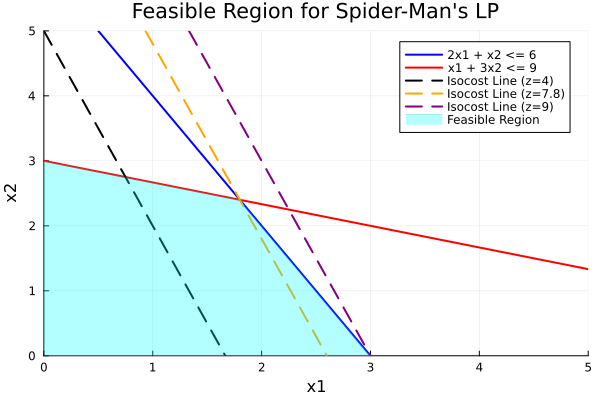

In [78]:
x1_range = 0:0.1:10
f1(x1) = 6 - 2*x1 
f2(x1) = 3 - (x1/3)

plot(x1_range, f1.(x1_range), label="2x1 + x2 <= 6", lw=2, color=:blue)
plot!(x1_range, f2.(x1_range), label="x1 + 3x2 <= 9", lw=2, color=:red)

# isocost lines
isocost_line(z, x1) = z - 3*x1  # Pass z as a parameter to the function
z = 5
plot!(x1_range, isocost_line.(z, x1_range), label="Isocost Line (z=4)", linestyle=:dash, lw=2, color=:black)
z = 27/5 + f1(9/5)
plot!(x1_range, isocost_line.(z, x1_range), label="Isocost Line (z=7.8)", linestyle=:dash, lw=2, color=:orange)
z = 9
plot!(x1_range, isocost_line.(z, x1_range), label="Isocost Line (z=9)", linestyle=:dash, lw=2, color=:purple)

# feasiable region
x_vals = [0, 3, 9/5, 0]
y_vals = [0, 0, f1(9/5), 3]

plot!(x_vals, y_vals, fill=(0, :cyan, 0.3), lw=0, label="Feasible Region")

xlabel!("x1")
ylabel!("x2")

title!("Feasible Region for Spider-Man's LP")

xlims!(0, 5)
ylims!(0, 5)


There is one unique optimal solotiuon to this LP

##### Question 3-2

The extreme points are (0,0), (0,3), (9/5,2.4) and (3,0)  
This problem has 0 rays because it is lower bounded by zero and the constraints are upper bounds i.e $\leq$

##### Question 3-3

$$ Ax = b $$
$$
A = \begin{bmatrix}
  0 & 0 & \frac{9}{5} & 3 \\
  0 & 3 & 2.4 & 0
\end{bmatrix}
$$
$$
x =
\begin{bmatrix}
  \lambda_1 \\
  \lambda_2 \\
  \lambda_3 \\
  \lambda_4
\end{bmatrix}
$$

$$
b =
\begin{bmatrix}
  1 \\
  1
\end{bmatrix}
$$

In [81]:
using LinearAlgebra

A = [0 0 9/5 3; 0 3 2.4 0]
b = [1; 1]
x = A \ b
x_normalized = x / norm(x)

println(x_normalized)


[0.0, 0.4356649189097368, 0.6931032800836721, 0.5742855749264709]
